In [ ]:
# https://huggingface.co/datasets/mlabonne/orpo-dpo-mix-40k-flat 
# from datasets import load_dataset

# ds = load_dataset("mlabonne/orpo-dpo-mix-40k-flat")
# ds

In [ ]:
# ds = ds['train']
# ds

In [ ]:
# ds[:5]

---

# M1 Pref Data Loaded in full and flattened

In [9]:
import json

def load_data(datapath):
    with open(datapath) as file:
        return json.load(file)

m1_data = load_data('../m1_preference_data.json')
len(m1_data)

1264

In [10]:
m1_data[:5]

[{'course_id': 15000,
  'question_id': 0,
  'question_body': 'Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   val n = l.size   if n <= 5 then     for i <- l do       if i == elem then         return true     false   else     val (p0, p1) = parallel(       contains(l.take(n / 2), elem),       contains(l.drop(n / 2), elem)     )   p0 || p1 Let $n$$n$ be the size of l. Assume that drop and take run in $\\Theta(1)$ on Vector and $\\Theta(n)$ on List. What is the asymptotic depth of contains if it is called on a List?',
  'question_options': None,
  'question_answer': 'In the same manner, $D(n) = D(n/2) + \\Theta(n)$ which is $\\Theta(n)$.',
  'question_type': 'open_answer',
  'preferences': [{'question_body': 'Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   

In [11]:
# flatten
# we have standard format only at the root:
# { question_id, question_body, question_options, question_answer, question_type, preferences {[]}, }
# inside preferences we have:
# {A, B, ranking_criteria {[]}, ... } where there might be other fields like question (again), reasoning, etc 
# ranking criteria is also standardized:
# 'ranking_criteria': {'overall': 'A',
#   'correctness': 'A',
#   'relevance': 'AB',
#   'clarity': 'AB',
#   'completeness': 'A',
#   'other': ''}}
m1_data[0]['preferences'][0]

{'question_body': 'Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   val n = l.size   if n <= 5 then     for i <- l do       if i == elem then         return true     false   else     val (p0, p1) = parallel(       contains(l.take(n / 2), elem),       contains(l.drop(n / 2), elem)     )   p0 || p1 Let $n$$n$ be the size of l. Assume that drop and take run in $\\Theta(1)$ on Vector and $\\Theta(n)$ on List. What is the asymptotic depth of contains if it is called on a List?',
 'question_options': None,
 'question_answer': 'In the same manner, $D(n) = D(n/2) + \\Theta(n)$ which is $\\Theta(n)$.',
 'question_type': 'open_answer',
 'A': 'The function `contains` divides the list into two halves and recursively checks for the element. Since taking and dropping elements from a list takes linear time, the overall time for each level of recursion is proportional to the size of the

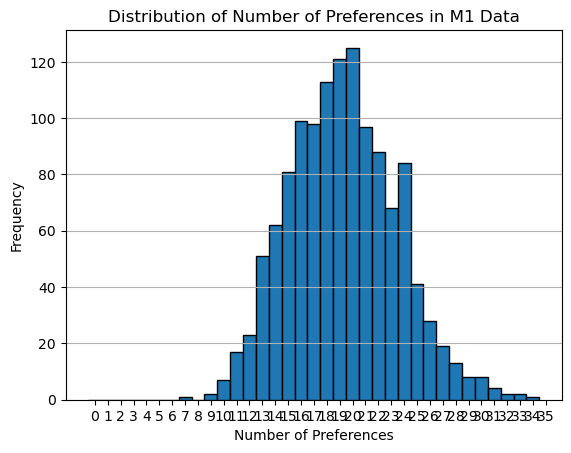

In [12]:
# let's plot the distribution of number of preferences
import matplotlib.pyplot as plt
import numpy as np
def plot_distribution(data, title):
    num_preferences = [len(item['preferences']) for item in data]
    plt.hist(num_preferences, bins=np.arange(0, max(num_preferences) + 1) - 0.5, edgecolor='black')
    plt.title(title)
    plt.xlabel('Number of Preferences')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(0, max(num_preferences) + 1))
    plt.grid(axis='y')
    plt.show()
plot_distribution(m1_data, 'Distribution of Number of Preferences in M1 Data')

In [13]:
# lets now flatten the data, we create a full version of the dataset which in preferences will have all the fields, then we can move on to clean it if necessary
# to leave everything as untouched as possible we just use A and B, because having 'chosen' and 'rejected'
# is already a discretionary choice (are we using overall, correctness, relevance, etc. as the main criteria?)
# but that will be the rational next step especially for DPO training
def flatten_data(data):
    flattened = []
    for item in data:
        for pref in item['preferences']:
            flat_item = {
                'question_id': item['question_id'],
                'question_body': item['question_body'],
                'question_options': item['question_options'],
                'question_answer': item['question_answer'],
                'question_type': item['question_type'],
                'A': pref.get('A', ''),
                'B': pref.get('B', ''),
                'ranking_criteria': pref.get('ranking_criteria', {}),
                #'reasoning': pref.get('reasoning', '')
            }
            flattened.append(flat_item)
    return flattened
flattened_m1_data = flatten_data(m1_data)
len(flattened_m1_data)

24365

In [14]:
flattened_m1_data[:5]

[{'question_id': 0,
  'question_body': 'Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   val n = l.size   if n <= 5 then     for i <- l do       if i == elem then         return true     false   else     val (p0, p1) = parallel(       contains(l.take(n / 2), elem),       contains(l.drop(n / 2), elem)     )   p0 || p1 Let $n$$n$ be the size of l. Assume that drop and take run in $\\Theta(1)$ on Vector and $\\Theta(n)$ on List. What is the asymptotic depth of contains if it is called on a List?',
  'question_options': None,
  'question_answer': 'In the same manner, $D(n) = D(n/2) + \\Theta(n)$ which is $\\Theta(n)$.',
  'question_type': 'open_answer',
  'A': 'The function `contains` divides the list into two halves and recursively checks for the element. Since taking and dropping elements from a list takes linear time, the overall time for each level of recursion is propor

In [15]:
# we can create a dataset and even push it to the hub now
from datasets import Dataset
flattened_m1_dataset = Dataset.from_list(flattened_m1_data)
flattened_m1_dataset

Dataset({
    features: ['question_id', 'question_body', 'question_options', 'question_answer', 'question_type', 'A', 'B', 'ranking_criteria'],
    num_rows: 24365
})

In [ ]:
# push to the hub
flattened_m1_dataset.push_to_hub("ciacco/m1_preference_data_flat", split="train", private=True)

In [ ]:
from datasets import load_dataset
m1_data = load_dataset("ciacco/m1_preference_data_flat", split="train")
m1_data

In [ ]:
# since the data is relatively small we can save a jsonl or json as well and add in lfs 
m1_data.to_json("../m1_preference_data_flat.jsonl",lines=True)

---

DPO - from the distribution above we see we have a roughly normal distribution of overlapping pairs, we can create a smaller dataset taking 6 or 7 pairs per question which should be more than enough repetition since we will combine it ewith high quality external datasets.

We could create a numerical score, using overall as main metric for chosen and rejected then the ranking criteria as added score. Since overall should be the most important and 'human' but we don't want to blatantly trust that a chosen answer might add up to a higher equal weight score than a rejected one, we might enforce for example a +5 for overall then a +1 for each ranking criteria that contains the answer. This would make for a score in the range 0 - 5 for a rejected answer and a 5-10 a chosen answer. Then filter by difference or something more fancy, or equivalently disregard overall and create a chosen and rejected based on average or sum of ranking criteria, then again we have correctness which should be taken as most important. 

for now lets simply take the first 7 pairs per question then we can always come back to the full flattened dataset if needed for improvements.


In [7]:
from datasets import load_dataset
ds = load_dataset("ciacco/m1_preference_data_flat", split="train")
ds

Dataset({
    features: ['question_id', 'question_body', 'question_options', 'question_answer', 'question_type', 'A', 'B', 'ranking_criteria'],
    num_rows: 24365
})

In [8]:
ds[0:1]

{'question_id': [0],
 'question_body': ['Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   val n = l.size   if n <= 5 then     for i <- l do       if i == elem then         return true     false   else     val (p0, p1) = parallel(       contains(l.take(n / 2), elem),       contains(l.drop(n / 2), elem)     )   p0 || p1 Let $n$$n$ be the size of l. Assume that drop and take run in $\\Theta(1)$ on Vector and $\\Theta(n)$ on List. What is the asymptotic depth of contains if it is called on a List?'],
 'question_options': [None],
 'question_answer': ['In the same manner, $D(n) = D(n/2) + \\Theta(n)$ which is $\\Theta(n)$.'],
 'question_type': ['open_answer'],
 'A': ['The function `contains` divides the list into two halves and recursively checks for the element. Since taking and dropping elements from a list takes linear time, the overall time for each level of recursion is p

In [16]:
# Create a DPO-formatted dataset with chosen/rejected pairs and criteria scores
def create_dpo_format(flattened_data):
    dpo_formatted = []
    
    criteria_keys = ['overall', 'correctness', 'relevance', 'clarity', 'completeness']
    
    for item in flattened_data:
        # Use 'overall' ranking as the primary preference indicator
        overall_preference = item['ranking_criteria'].get('overall', '')
        
        if overall_preference in ['A', 'B']:
            # Calculate scores for A and B
            score_A = 0
            score_B = 0
            
            for criterion in criteria_keys:
                criterion_val = item['ranking_criteria'].get(criterion, '')
                if 'A' in criterion_val:
                    score_A += 1
                if 'B' in criterion_val:
                    score_B += 1
            
            # Extra weight for overall preference
            if overall_preference == 'A':
                score_A += 3
            else:
                score_B += 3
                
            dpo_item = {
                'question_id': item['question_id'],
                'prompt': item['question_body'] ,
                'chosen': item['A'] if overall_preference == 'A' else item['B'],
                'rejected': item['B'] if overall_preference == 'A' else item['A'],
                'chosen_score': score_A if overall_preference == 'A' else score_B,
                'rejected_score': score_B if overall_preference == 'A' else score_A,
                #'score_diff': abs(score_A - score_B),
                'question_type': item['question_type'],
                #'ranking_criteria': item['ranking_criteria'],
                'question_options': item['question_options'],
                'question_answer': item['question_answer'],
            }
            dpo_formatted.append(dpo_item)
    
    return dpo_formatted

In [17]:
dpo_data = create_dpo_format(ds.to_list())
dpo_data[:5]

[{'question_id': 0,
  'prompt': 'Consider the following contains function defined on Iterable (in particular, it accepts both Vector and List).  def contains[A](l: Iterable[A], elem: A): Boolean =   val n = l.size   if n <= 5 then     for i <- l do       if i == elem then         return true     false   else     val (p0, p1) = parallel(       contains(l.take(n / 2), elem),       contains(l.drop(n / 2), elem)     )   p0 || p1 Let $n$$n$ be the size of l. Assume that drop and take run in $\\Theta(1)$ on Vector and $\\Theta(n)$ on List. What is the asymptotic depth of contains if it is called on a List?',
  'chosen': 'The function `contains` divides the list into two halves and recursively checks for the element. Since taking and dropping elements from a list takes linear time, the overall time for each level of recursion is proportional to the size of the list, which is `Θ(n)`. Therefore, the depth of the function when called on a List is `Θ(n)` because each recursive call adds a linear 

In [19]:
len(dpo_data)

24240

In [18]:
# push to hub 
dpo_dataset = Dataset.from_list(dpo_data)
dpo_dataset.push_to_hub("ciacco/m1_preference_data_dpo", split="train", private=True)
# save as jsonl
dpo_dataset.to_json("../m1_preference_data_dpo.jsonl", lines=True)
# load the dataset back
dpo_dataset = load_dataset("ciacco/m1_preference_data_dpo", split="train")
dpo_dataset

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/25 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/25 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/607 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/31.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24240 [00:00<?, ? examples/s]

Dataset({
    features: ['question_id', 'prompt', 'chosen', 'rejected', 'chosen_score', 'rejected_score', 'question_type', 'question_options', 'question_answer'],
    num_rows: 24240
})

Note: we dropped 24365-24240 = 125 samples that had overall neither A nor B

## Visualization of scores

/Users/jacopoferro/opt/anaconda3/envs/modern_nlp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jacopoferro/opt/anaconda3/envs/modern_nlp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


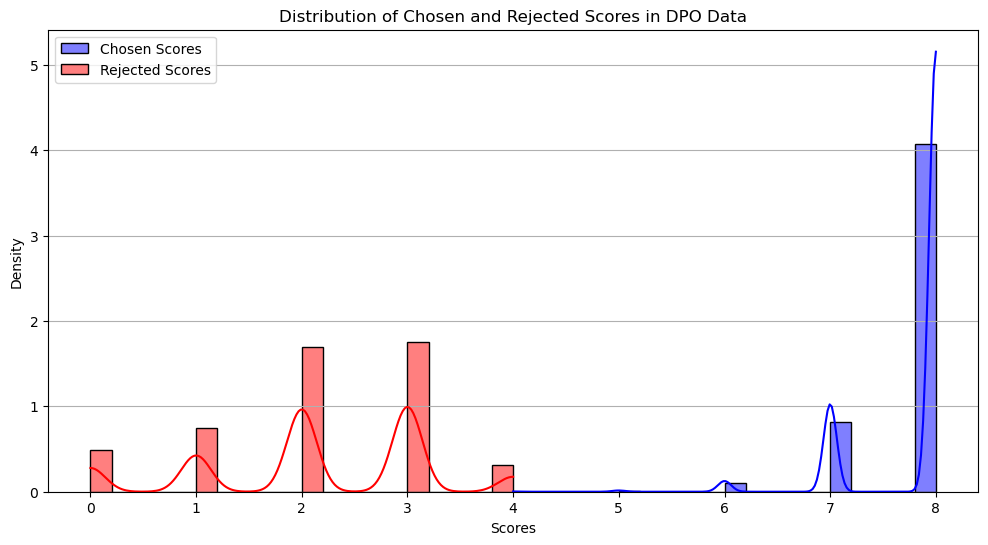

In [20]:
# some visualization of scores for rejected and chosen
import seaborn as sns
def plot_scores_distribution(data, title):
    chosen_scores = [item['chosen_score'] for item in data]
    rejected_scores = [item['rejected_score'] for item in data]
    
    plt.figure(figsize=(12, 6))
    sns.histplot(chosen_scores, bins=20, color='blue', label='Chosen Scores', kde=True, stat='density')
    sns.histplot(rejected_scores, bins=20, color='red', label='Rejected Scores', kde=True, stat='density')
    
    plt.title(title)
    plt.xlabel('Scores')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y')
    plt.show()
plot_scores_distribution(dpo_data, 'Distribution of Chosen and Rejected Scores in DPO Data')

/Users/jacopoferro/opt/anaconda3/envs/modern_nlp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jacopoferro/opt/anaconda3/envs/modern_nlp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jacopoferro/opt/anaconda3/envs/modern_nlp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


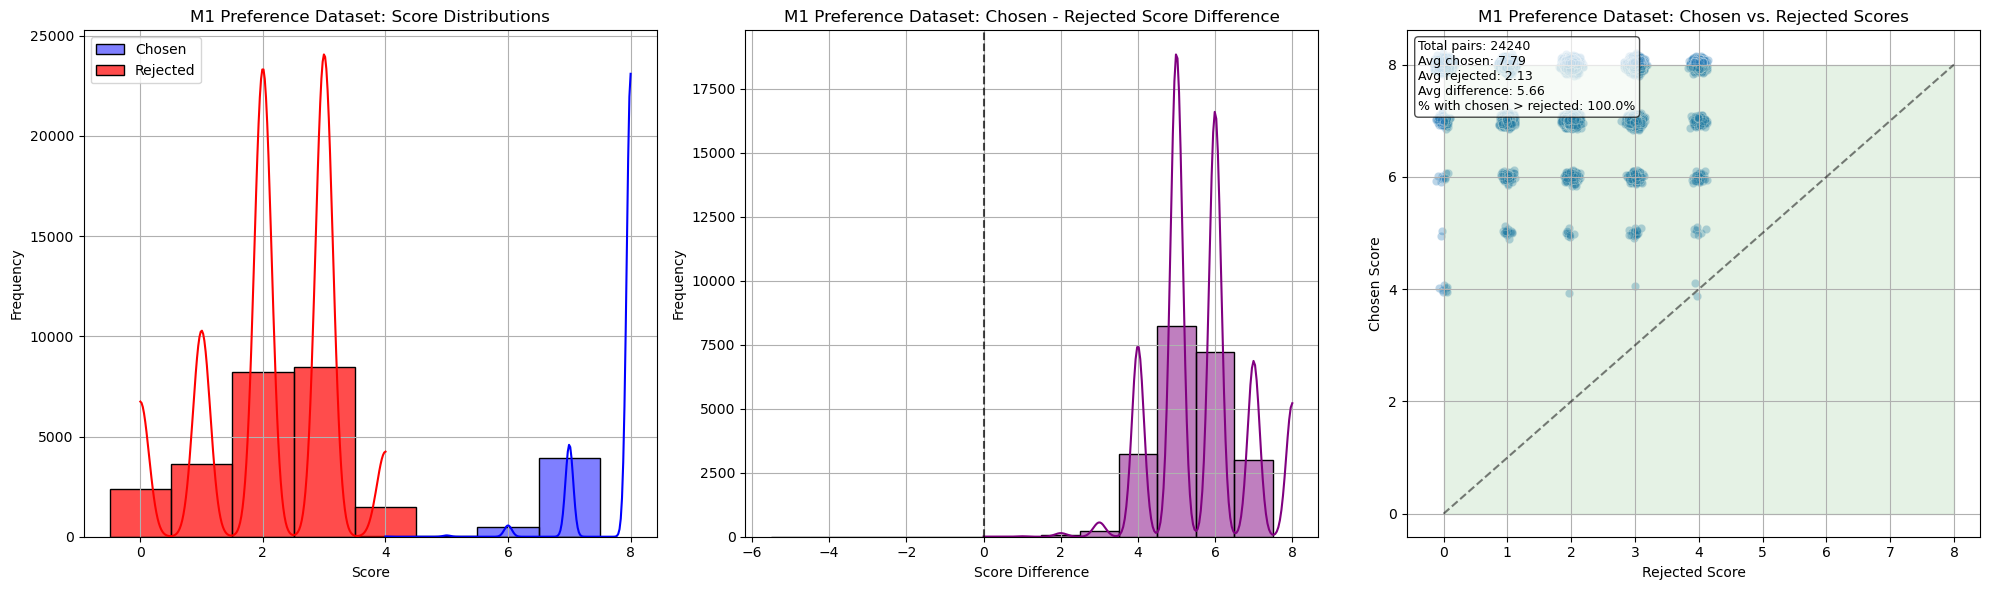

DPO Score Analysis Summary:
- Total pairs: 24240
- Mean chosen score: 7.79
- Mean rejected score: 2.13
- Mean difference: 5.66
- Median difference: 6.00
- Pairs with chosen > rejected: 24238 (100.0%)
- Pairs with chosen = rejected: 2 (0.0%)
- Pairs with chosen < rejected: 0 (0.0%)


In [25]:
# another better visualization
# Comprehensive visualization of DPO data scores
def plot_dpo_score_analysis(data, title_prefix="DPO Score Analysis"):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    
    # Extract scores
    chosen_scores = [item['chosen_score'] for item in data]
    rejected_scores = [item['rejected_score'] for item in data]
    score_diffs = [c - r for c, r in zip(chosen_scores, rejected_scores)]
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: Distribution of chosen and rejected scores
    sns.histplot(chosen_scores, bins=np.arange(0, 9) - 0.5, color='blue', 
                 label='Chosen', kde=True, ax=axes[0])
    sns.histplot(rejected_scores, bins=np.arange(0, 9) - 0.5, color='red', 
                 label='Rejected', kde=True, ax=axes[0], alpha=0.7)
    
    axes[0].set_title(f"{title_prefix}: Score Distributions")
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Score differences histogram
    sns.histplot(score_diffs, bins=np.arange(-5, 9) - 0.5, color='purple', 
                 kde=True, ax=axes[1])
    axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.7)
    axes[1].set_title(f"{title_prefix}: Chosen - Rejected Score Difference")
    axes[1].set_xlabel('Score Difference')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True)
    
    # Plot 3: Scatterplot with marginal distributions
    df = pd.DataFrame({
        'Chosen Score': chosen_scores,
        'Rejected Score': rejected_scores
    })
    
    # Add some jitter to show density better
    scatter = sns.scatterplot(x=np.array(rejected_scores) + np.random.normal(0, 0.05, len(rejected_scores)),
                             y=np.array(chosen_scores) + np.random.normal(0, 0.05, len(chosen_scores)),
                             alpha=0.3, ax=axes[2])
    
    # Add diagonal line where scores are equal
    max_val = max(max(chosen_scores), max(rejected_scores))
    axes[2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Shade the region where chosen score > rejected score
    axes[2].fill_between([0, max_val], [0, 0], [max_val, max_val], 
                        color='green', alpha=0.1)
    
    axes[2].set_title(f"{title_prefix}: Chosen vs. Rejected Scores")
    axes[2].set_xlabel('Rejected Score')
    axes[2].set_ylabel('Chosen Score')
    axes[2].grid(True)
    
    # Add textbox with statistics
    stats_text = (
        f"Total pairs: {len(data)}\n"
        f"Avg chosen: {np.mean(chosen_scores):.2f}\n"
        f"Avg rejected: {np.mean(rejected_scores):.2f}\n"
        f"Avg difference: {np.mean(score_diffs):.2f}\n"
        f"% with chosen > rejected: {(np.array(score_diffs) > 0).mean() * 100:.1f}%"
    )
    axes[2].text(0.02, 0.98, stats_text, transform=axes[2].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis: print summary statistics
    print(f"DPO Score Analysis Summary:")
    print(f"- Total pairs: {len(data)}")
    print(f"- Mean chosen score: {np.mean(chosen_scores):.2f}")
    print(f"- Mean rejected score: {np.mean(rejected_scores):.2f}")
    print(f"- Mean difference: {np.mean(score_diffs):.2f}")
    print(f"- Median difference: {np.median(score_diffs):.2f}")
    print(f"- Pairs with chosen > rejected: {sum(s > 0 for s in score_diffs)} ({(np.array(score_diffs) > 0).mean() * 100:.1f}%)")
    print(f"- Pairs with chosen = rejected: {sum(s == 0 for s in score_diffs)} ({(np.array(score_diffs) == 0).mean() * 100:.1f}%)")
    print(f"- Pairs with chosen < rejected: {sum(s < 0 for s in score_diffs)} ({(np.array(score_diffs) < 0).mean() * 100:.1f}%)")

# Call the function with your data
plot_dpo_score_analysis(dpo_data, "M1 Preference Dataset")